# Phân loại Email Spam
## 4. Phân tích khám phá dữ liệu (EDA)

Trong phần này, chúng ta phân tích các thuộc tính thống kê và mẫu văn bản của email để tìm ra các đặc trưng phân biệt giữa Spam và Ham.

Các nội dung phân tích:
1. Thống kê mô tả độ dài ký tự và số lượng từ
2. Trực quan hóa phân phối độ dài văn bản
3. Trích xuất và trực quan hóa 20 từ xuất hiện nhiều nhất
4. Trích xuất và trực quan hóa 20 cụm 2 từ (Bigram) xuất hiện nhiều nhất
5. Tỷ lệ email có tiêu đề (Subject) theo từng lớp


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, os, warnings
from collections import Counter
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

df = pd.read_csv(r'./data/preprocessed/enron_cleaned.csv')
df['text'] = df['text'].fillna('')
df['Subject'] = df['Subject'].fillna('')

df['text_len']   = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

spam = df[df['label'] == 'spam']
ham  = df[df['label'] == 'ham']
print(f'Mẫu Spam: {len(spam):,}  |  Mẫu Ham: {len(ham):,}')

Mẫu Spam: 17,120  |  Mẫu Ham: 16,545


### 4.2 Biểu đồ phân phối độ dài ký tự và từ

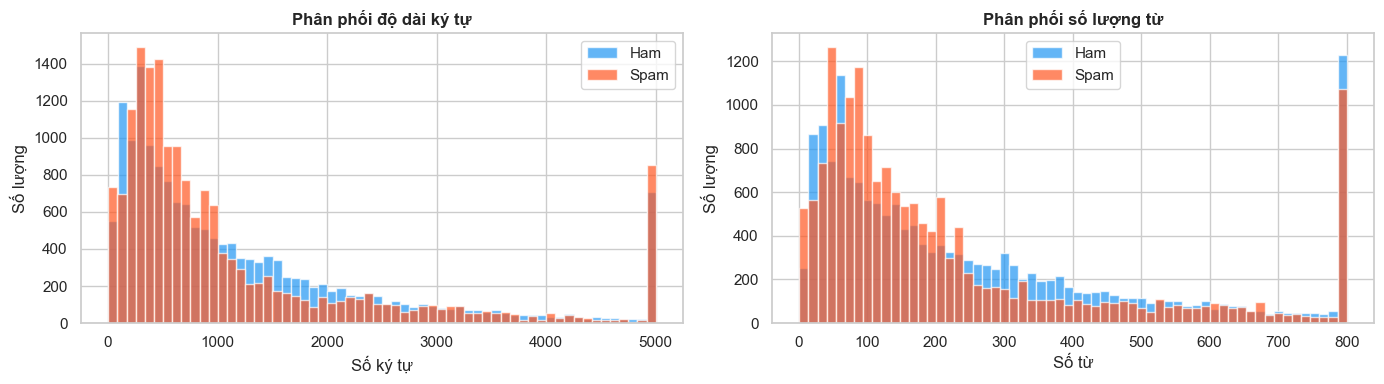

Thống kê mô tả Spam:
       text_len  word_count
count   17120.0     17120.0
mean     1314.1       262.0
std      1956.6       386.8
min         2.0         1.0
25%       345.0        71.0
50%       652.0       137.0
75%      1378.2       276.0
max     28752.0      8401.0

Thống kê mô tả Ham:
       text_len  word_count
count   16545.0     16545.0
mean     1708.4       361.8
std      5774.4      1147.7
min         3.0         1.0
25%       338.0        73.0
50%       795.0       175.0
75%      1696.0       372.0
max    228368.0     45450.0


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Phân phối độ dài ký tự
axes[0].hist(ham['text_len'].clip(upper=5000),  bins=60, alpha=0.7, label='Ham',  color='#2196F3')
axes[0].hist(spam['text_len'].clip(upper=5000), bins=60, alpha=0.7, label='Spam', color='#FF5722')
axes[0].set_title('Phân phối độ dài ký tự', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Số ký tự')
axes[0].set_ylabel('Số lượng')
axes[0].legend()

# Phân phối số lượng từ
axes[1].hist(ham['word_count'].clip(upper=800),  bins=60, alpha=0.7, label='Ham',  color='#2196F3')
axes[1].hist(spam['word_count'].clip(upper=800), bins=60, alpha=0.7, label='Spam', color='#FF5722')
axes[1].set_title('Phân phối số lượng từ', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số từ')
axes[1].set_ylabel('Số lượng')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Thống kê mô tả Spam:')
print(spam[['text_len', 'word_count']].describe().round(1))
print('\nThống kê mô tả Ham:')
print(ham[['text_len', 'word_count']].describe().round(1))

### 4.3 Top 20 từ phổ biến nhất — Spam vs. Ham

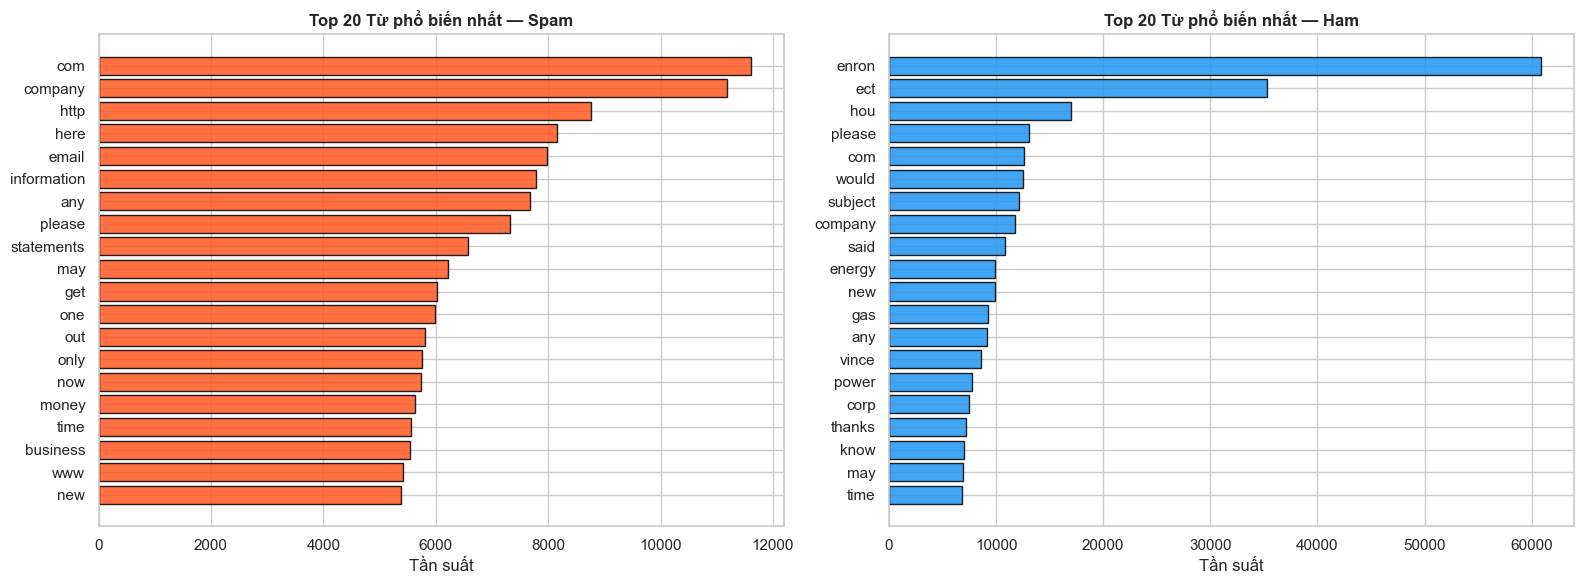

In [38]:
# Danh sách stop words tiếng Anh cơ bản dùng riêng cho trực quan hóa
BASIC_SW = {'the','and','to','of','a','in','is','it','that','this','for',
            'you','are','on','be','with','as','have','at','or','was','from',
            'by','but','an','not','your','our','we','i','will','can','has',
            'he','she','they','do','so','if','all','their','been','more',
            'had','about','than','also','its','which'}

def get_top_words(series, n=20):
    words = []
    for text in series:
        tokens = re.findall(r'[a-zA-Z]+', str(text).lower())
        words.extend([w for w in tokens if w not in BASIC_SW and len(w) > 2])
    return Counter(words).most_common(n)

spam_words = get_top_words(spam['text'])
ham_words  = get_top_words(ham['text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, wlist, label, color in zip(
    axes,
    [spam_words, ham_words],
    ['Spam', 'Ham'],
    ['#FF5722', '#2196F3']
):
    words, cnts = zip(*wlist)
    ax.barh(list(reversed(words)), list(reversed(cnts)),
            color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'Top 20 Từ phổ biến nhất — {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tần suất')

plt.tight_layout()
plt.show()

### 4.3.2 Lọc các từ phổ biến đặc trưng cho Spam (Không nằm trong Top 20 của Ham)

Để hiểu rõ hơn các từ đặc trưng cho email quảng cáo rác (Spam) mà ít xuất hiện trong email thông thường (Ham), chúng ta tiến hành lọc ra danh sách 20 từ phổ biến nhất ở Spam nhưng KHÔNG thuộc Top 20 từ phổ biến nhất của Ham.

In [39]:
# Lấy danh sách Top 20 từ phổ biến nhất của Ham
top_20_ham_words = {w for w, _ in ham_words}

# Lọc và tìm 20 từ phổ biến nhất trong Spam mà không thuộc top_20_ham_words
words_spam_all = []
for text in spam['text']:
    tokens = re.findall(r'[a-zA-Z]+', str(text).lower())
    words_spam_all.extend([w for w in tokens if w not in BASIC_SW and len(w) > 2])

spam_counter = Counter(words_spam_all)
spam_words_filtered = []
for w, c in spam_counter.most_common():
    if w not in top_20_ham_words:
        spam_words_filtered.append((w, c))
        if len(spam_words_filtered) == 20:
            break

# Tạo DataFrame hiển thị
df_spam_filtered = pd.DataFrame(spam_words_filtered, columns=['Từ khóa (Spam)', 'Tần suất'])
print("BẢNG LỌC: 20 TỪ PHỔ BIẾN NHẤT Ở SPAM NHƯNG KHÔNG NẰM TRONG TOP 20 CỦA HAM")
print("=" * 75)
print(df_spam_filtered.to_string(index=False))


BẢNG LỌC: 20 TỪ PHỔ BIẾN NHẤT Ở SPAM NHƯNG KHÔNG NẰM TRONG TOP 20 CỦA HAM
Từ khóa (Spam)  Tần suất
          http      8755
          here      8157
         email      7985
   information      7792
    statements      6579
           get      6027
           one      5980
           out      5813
          only      5760
           now      5741
         money      5635
      business      5544
           www      5410
          mail      4836
          over      4763
         price      4738
          free      4720
        within      4708
        report      4413
         these      4314


### 4.4 Top 20 Bigrams phổ biến nhất — Spam vs. Ham

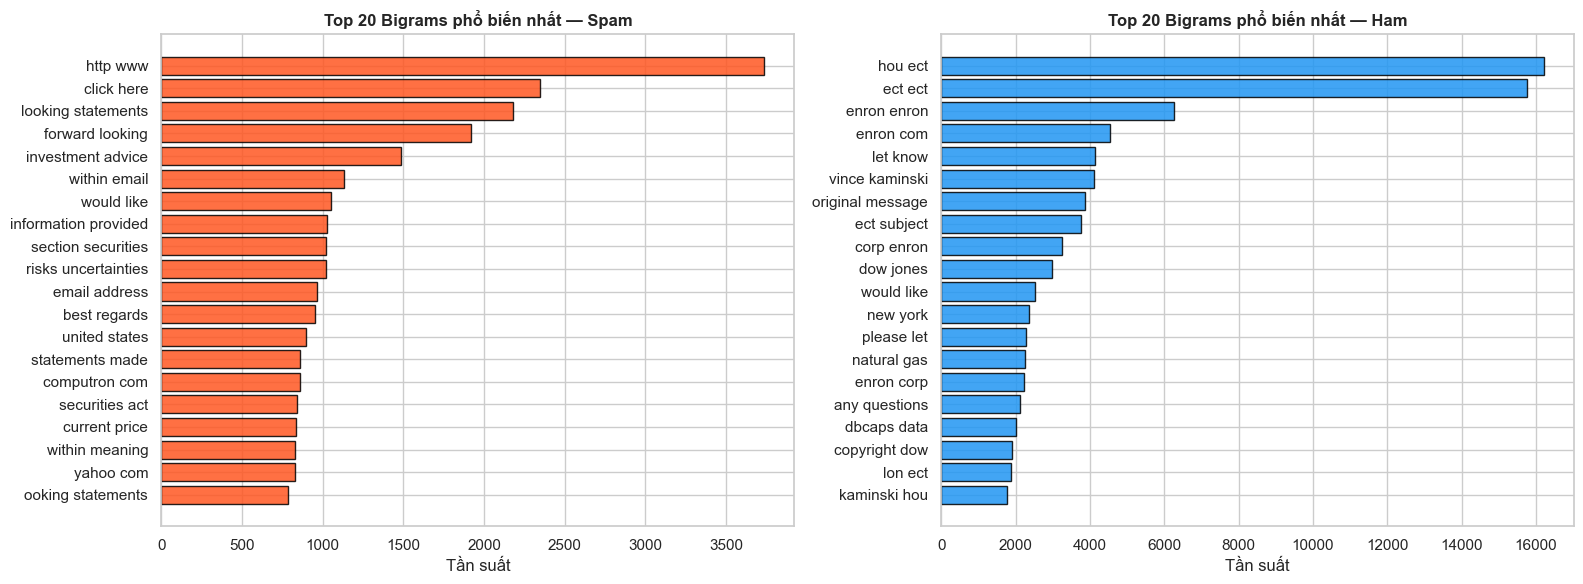

In [40]:
def get_top_bigrams(series, n=20):
    bigrams = []
    for text in series:
        tokens = re.findall(r'[a-zA-Z]+', str(text).lower())
        tokens = [w for w in tokens if w not in BASIC_SW and len(w) > 2]
        bg_list = [f"{tokens[i]} {tokens[i+1]}" for i in range(len(tokens) - 1)]
        bigrams.extend(bg_list)
    return Counter(bigrams).most_common(n)

spam_bigrams = get_top_bigrams(spam['text'])
ham_bigrams  = get_top_bigrams(ham['text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, wlist, label, color in zip(
    axes,
    [spam_bigrams, ham_bigrams],
    ['Spam', 'Ham'],
    ['#FF5722', '#2196F3']
):
    if wlist:
        words, cnts = zip(*wlist)
    else:
        words, cnts = ([], [])
    ax.barh(list(reversed(words)), list(reversed(cnts)),
            color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'Top 20 Bigrams phổ biến nhất — {label}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tần suất')

plt.tight_layout()
plt.show()

### 4.5 Sự xuất hiện của tiêu đề email theo từng lớp

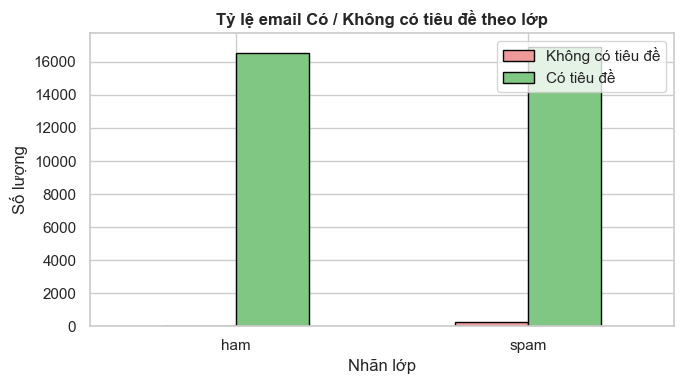

In [41]:
df['has_subject'] = df['Subject'].apply(lambda x: len(str(x).strip()) > 0)

fig, ax = plt.subplots(figsize=(7, 4))
has_subj = df.groupby(['label', 'has_subject']).size().unstack(fill_value=0)
has_subj.plot(kind='bar', ax=ax, color=['#EF9A9A', '#81C784'],
              edgecolor='black')
ax.set_title('Tỷ lệ email Có / Không có tiêu đề theo lớp', fontsize=12, fontweight='bold')
ax.set_xlabel('Nhãn lớp')
ax.set_ylabel('Số lượng')
ax.legend(['Không có tiêu đề', 'Có tiêu đề'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.6 Phân tích tần suất các ký tự đặc biệt đặc trưng (! và $)

Để trả lời câu hỏi liệu các ký tự đặc biệt như dấu chấm hay dấu phẩy là phổ biến, còn dấu chấm than (`!`) và ký tự đô-la (`$`) có thực sự là đặc trưng riêng biệt của email quảng cáo/rác (Spam) hay không, chúng ta tiến hành thống kê tần suất xuất hiện trung bình của chúng trên từng email theo từng lớp.

Tần suất xuất hiện trung bình của ký tự đặc biệt trên mỗi email:
       exclamation_count  dollar_count
label                                 
ham               0.6312        1.1440
spam              1.8757        1.3829


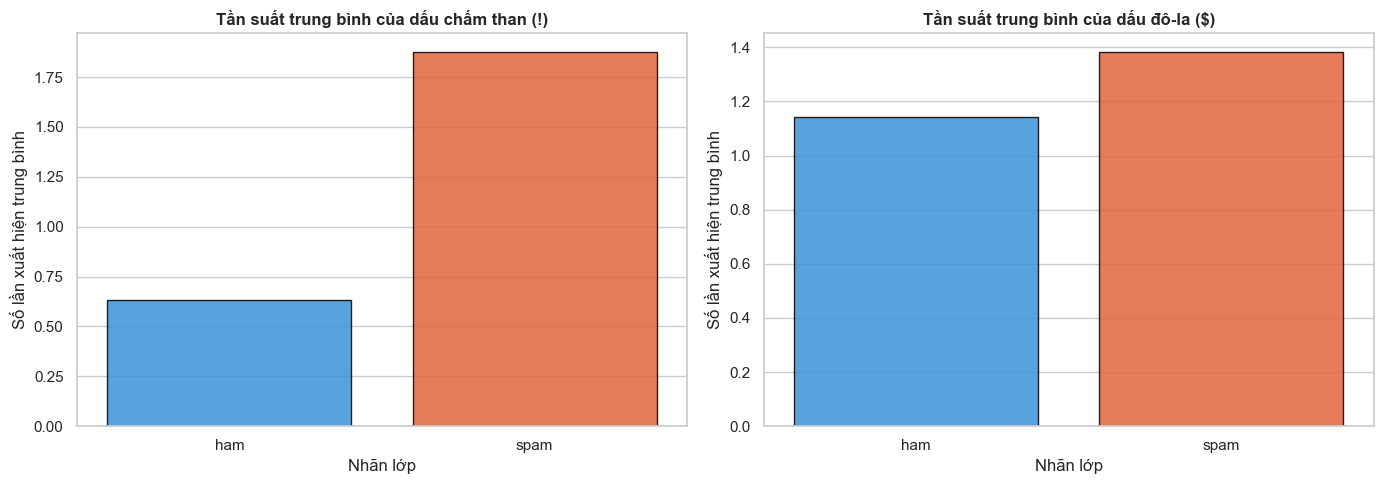

In [42]:
# Tính toán tần suất xuất hiện của ký tự ! và $ trong từng email
df['exclamation_count'] = df['text'].apply(lambda x: str(x).count('!'))
df['dollar_count']      = df['text'].apply(lambda x: str(x).count('$'))

# Tính toán giá trị trung bình theo từng lớp
avg_chars = df.groupby('label')[['exclamation_count', 'dollar_count']].mean()
print("Tần suất xuất hiện trung bình của ký tự đặc biệt trên mỗi email:")
print(avg_chars.round(4))

# Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ cho dấu chấm than
sns.barplot(x=avg_chars.index, y=avg_chars['exclamation_count'], ax=axes[0],
            palette=['#2196F3', '#FF5722'], edgecolor='black', alpha=0.85)
axes[0].set_title('Tần suất trung bình của dấu chấm than (!)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Số lần xuất hiện trung bình')
axes[0].set_xlabel('Nhãn lớp')

# Biểu đồ cho dấu đô-la
sns.barplot(x=avg_chars.index, y=avg_chars['dollar_count'], ax=axes[1],
            palette=['#2196F3', '#FF5722'], edgecolor='black', alpha=0.85)
axes[1].set_title('Tần suất trung bình của dấu đô-la ($)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Số lần xuất hiện trung bình')
axes[1].set_xlabel('Nhãn lớp')

plt.tight_layout()
plt.show()
